# 07 - Context Geometry: Real Surrounding-Block Occluders

**The realistic demo.** `client.buildings.get_area(polygon)` fetches buildings
**inside** the polygon only - so a facade study on a small AOI misses the
shadows cast by the surrounding blocks. `context-geometry` fixes that: it is
geometry that **occludes** (casts shadows / blocks sky) exactly like
`geometries`, but never receives synthesized sensors and never enters the grid
mask. *"Trace everything, measure only these."*

**The recipe**

1. Fetch a **larger** polygon (a ~200 m halo around the target AOI).
2. **Split** it: buildings in the inner AOI = *target*; the rest = *context*.
3. Run facade solar radiation on the target **twice** - once without context,
   once with the surrounding blocks as `context-geometry`.
4. Look at the **before / after shadowing delta** per facade.

`context-geometry` needs a trigger (one of `analysis-surfaces`,
`sensor-points`, or `ground-geometry`) - here `analysis-surfaces` provides it.

**When to use.** Any facade / SVF / sun-hours study where the neighbours
matter (i.e. almost always in a real city).

## Setup

In [1]:
# --- Setup: auth, base URL, geometry (self-contained) -----------------------
# Set your key in the environment first:  export INFRARED_API_KEY=...
# Optionally load a .env file (pip install python-dotenv):
try:
    from dotenv import load_dotenv

    load_dotenv()
except Exception:
    pass

import os

# Default base URL = STAGING (host root, NO /v2) where advanced features deploy
# first. For production set INFRARED_BASE_URL=https://api.infrared.city/v2
os.environ.setdefault("INFRARED_BASE_URL", "https://api-test.infrared.city")

import numpy as np
import ir_advanced as ia
import ir_render as ir

print("base URL :", ia.base_url())
client = ia.make_client()
buildings = ia.fetch_buildings(
    client, ia.VIENNA_KARLSPLATZ, "karlsplatz_buildings.json"
)
print(f"buildings: {len(buildings)} (Vienna Karlsplatz AOI, fetched via SDK + cached)")

base URL : https://api-test.infrared.city


buildings: 132 (Vienna Karlsplatz AOI, fetched via SDK + cached)


In [2]:
# Weather: nearest TMY file to the AOI, filtered to the analysis window.
from infrared_sdk.models import TimePeriod, Location

weather_id = ia.fetch_weather_identifier(client)
print("weather file:", weather_id)

weather file: AUT_WI_Wien-Innere.Stadt.110340_TMYx.2009-2023


## Fetch the larger area and split target vs context

We grow the Karlsplatz AOI by a 200 m halo, fetch all buildings in that larger
polygon (one consistent meter frame), then label each building target / context
by whether its centroid is in the inner AOI.

In [3]:
import ir_context as ic

inner = ia.VIENNA_KARLSPLATZ
outer = ic.expand_polygon(inner, halo_m=200.0, ref_lat=ia.VIENNA_LAT)
big = ia.fetch_buildings(client, outer, "context_buildings.json")

rect = ic.inner_rect_local(inner, outer, ia.VIENNA_LAT)
target_ids, context_ids = ic.split_target_context(big, rect)
target = ic.subset(big, target_ids)
context = ic.subset(big, context_ids)
print(f"outer area buildings : {len(big)}")
print(f"target (inner AOI)   : {len(target)}")
print(f"context (surrounding): {len(context)}")

outer area buildings : 637
target (inner AOI)   : 24
context (surrounding): 613


Plan view - the split. Blue = target buildings we measure; grey = context occluders.

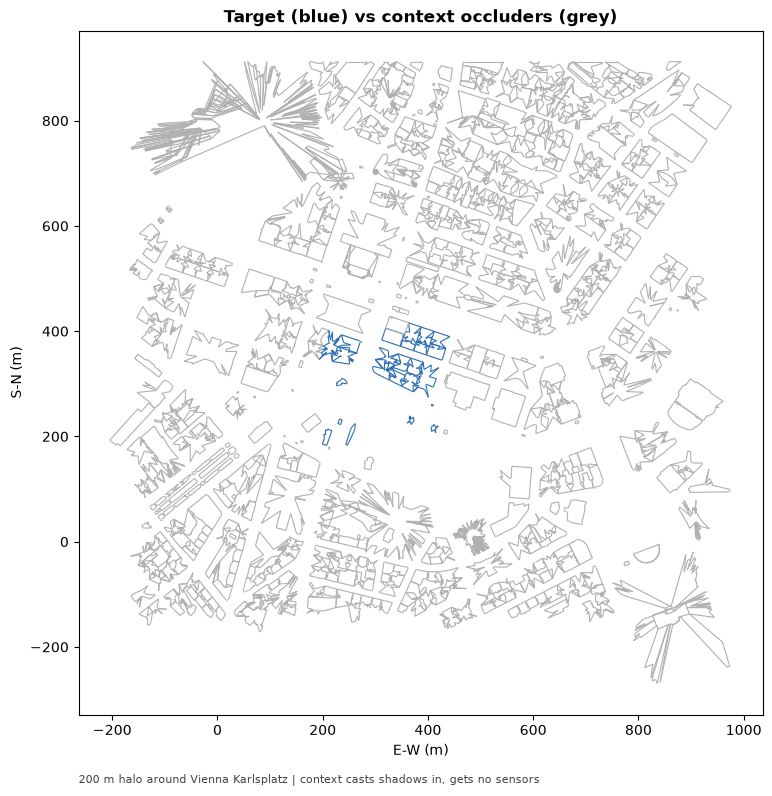

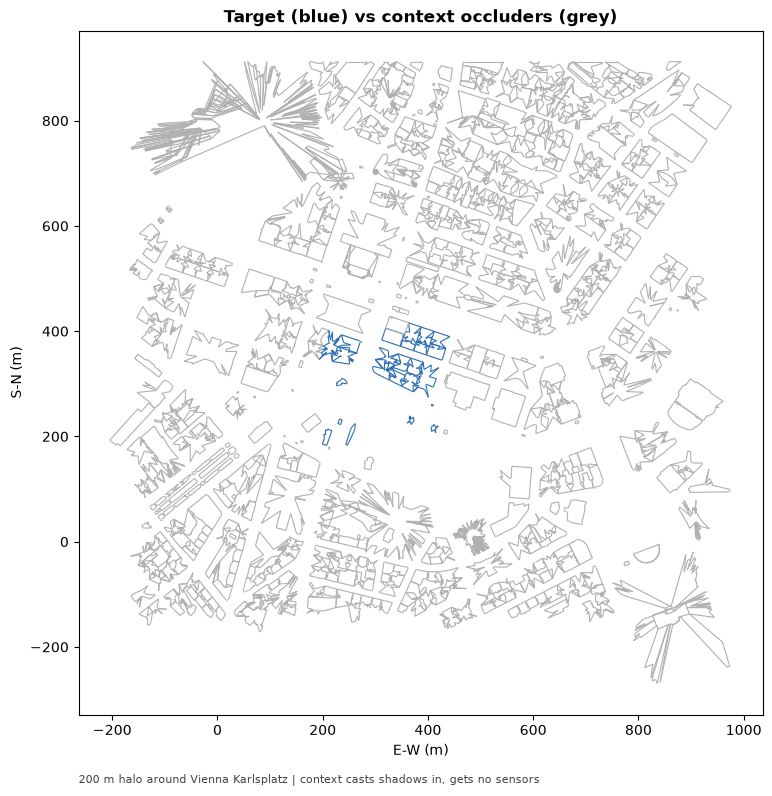

In [4]:
fig, ax = ir.footprints_2d(
    big,
    target_ids=target_ids,
    title="Target (blue) vs context occluders (grey)",
    note="200 m halo around Vienna Karlsplatz | context casts shadows in, gets no sensors",
)
fig

## Run facade solar radiation - without vs with context

Same target buildings, same facade synthesis. The only difference is the
`context-geometry` block in the second payload.

In [5]:
from infrared_sdk.analyses.types import (
    SolarRadiationModelRequest,
    BaseAnalysisPayload,
    AnalysesName,
)

tp = TimePeriod(
    start_month=7, start_day=15, start_hour=9, end_month=7, end_day=15, end_hour=17
)
loc = Location(latitude=ia.VIENNA_LAT, longitude=ia.VIENNA_LON)
wp = client.weather.filter_weather_data(identifier=weather_id, time_period=tp)


def facade_body():
    b = SolarRadiationModelRequest.from_weatherfile_payload(
        BaseAnalysisPayload(analysis_type=AnalysesName.solar_radiation), loc, tp, wp
    ).to_dict()
    b["latitude"] = ia.VIENNA_LAT
    b["longitude"] = ia.VIENNA_LON
    b["geometries"] = target
    b["analysis-surfaces"] = "facades"
    b["surface-grid-size"] = 4.0
    b["surface-offset"] = 0.1
    return b


# WITHOUT context - target buildings shade each other, but the neighbours are invisible.
no_ctx, info_a = ia.run_job("solar-radiation", facade_body(), label="no-context")

# WITH context - the surrounding blocks now cast shadows onto the target facades.
body = facade_body()
body["context-geometry"] = context  # <-- the only change
with_ctx, info_b = ia.run_job("solar-radiation", body, label="with-context")
print(
    "sensors (identical both runs):", no_ctx["sensor-count"], with_ctx["sensor-count"]
)

[solar-radiation/no-context] Succeeded in 0.5s  keys=['aggregates', 'max-legend', 'min-legend', 'sensor-count', 'surfaces']  sensors=8264


[solar-radiation/with-context] Succeeded in 1.4s  keys=['aggregates', 'max-legend', 'min-legend', 'sensor-count', 'surfaces']  sensors=8264
sensors (identical both runs): 8264 8264


### Result payload, described

Both runs return the **surface** payload of notebook `01`
(`surfaces` / `aggregates` / `sensor-count`) for the **target** buildings only
- the context never appears in the output. Because the sensor layout is
identical, we can subtract per-cell and per-building between the two runs to
isolate the **shadowing effect of the neighbours**.

`context-geometry` notes:
* it needs a trigger (here `analysis-surfaces`); on the flat grid path alone it
  is rejected with 422.
* on **advanced/detail UTCI** it just merged (PR #119) but is **not live**
  until the next staging re-deploy - use `physics:"v1"` for context on a
  thermal run until then.

## The money shot - irradiance lost to the neighbours

Per building, how much facade irradiance did the surrounding blocks remove?

mean facade irradiance:  no-context 0.835  ->  with-context 0.789 kWh/m2
context removes on average -0.046 kWh/m2 per building
most-overshadowed building loses -0.219 kWh/m2


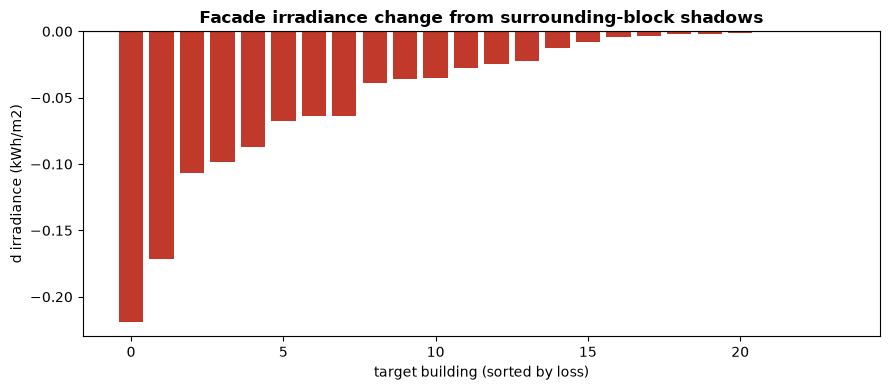

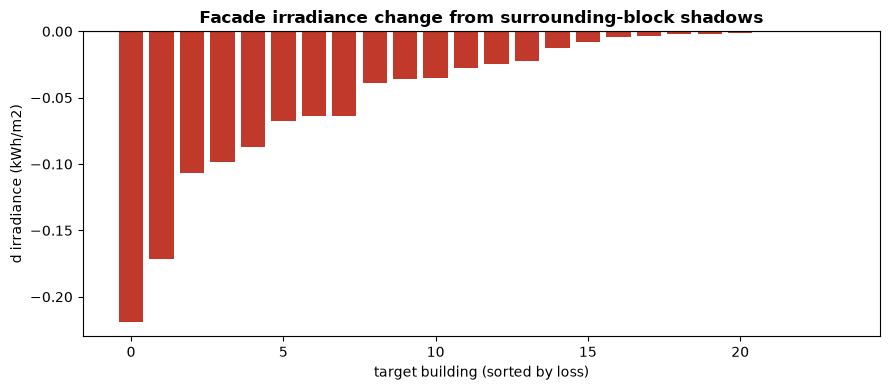

In [6]:
m_no = ic.aggregate_means(no_ctx)
m_with = ic.aggregate_means(with_ctx)
common = sorted(set(m_no) & set(m_with))
deltas = np.array([m_with[b] - m_no[b] for b in common])

print(
    "mean facade irradiance:  no-context %.3f  ->  with-context %.3f kWh/m2"
    % (
        float(np.mean([m_no[b] for b in common])),
        float(np.mean([m_with[b] for b in common])),
    )
)
print("context removes on average %+.3f kWh/m2 per building" % float(np.mean(deltas)))
print("most-overshadowed building loses %.3f kWh/m2" % float(np.min(deltas)))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
order = np.argsort(deltas)
ax.bar(range(len(common)), deltas[order], color="#c0392b")
ax.axhline(0, color="#333", lw=0.8)
ax.set_xlabel("target building (sorted by loss)")
ax.set_ylabel("d irradiance (kWh/m2)")
ax.set_title("Facade irradiance change from surrounding-block shadows", weight="bold")
fig.tight_layout()
fig

## Render - the same facades, with and without context

Reconstruct both as colored meshes on the **same** target geometry, on a
shared color scale, so the darkening from the neighbours is directly visible.

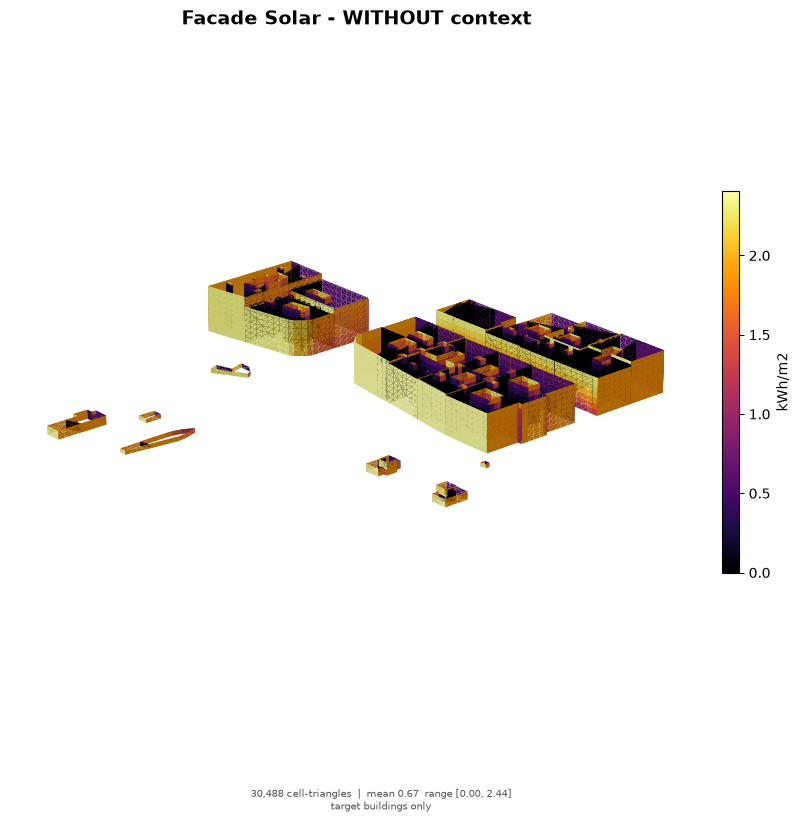

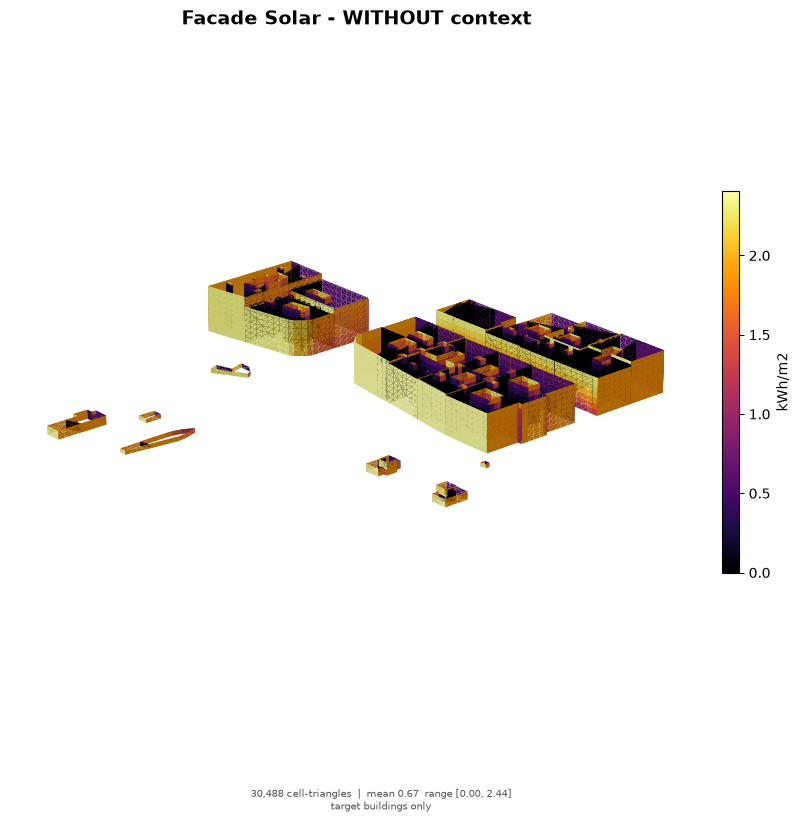

In [7]:
t_no, v_no, n_no = ia.reconstruct_cells(no_ctx["surfaces"])
t_wi, v_wi, n_wi = ia.reconstruct_cells(with_ctx["surfaces"])
faces = ia.building_faces(target)
lo = float(np.percentile(np.concatenate([v_no, v_wi]), 2))
hi = float(np.percentile(np.concatenate([v_no, v_wi]), 98))

fig, ax = ir.surface_mesh(
    t_no,
    v_no,
    normals=n_no,
    context_faces=faces,
    vmin=lo,
    vmax=hi,
    zmax=45,
    title="Facade Solar - WITHOUT context",
    cbar_label="kWh/m2",
    cmap="inferno",
    note="target buildings only",
)
fig

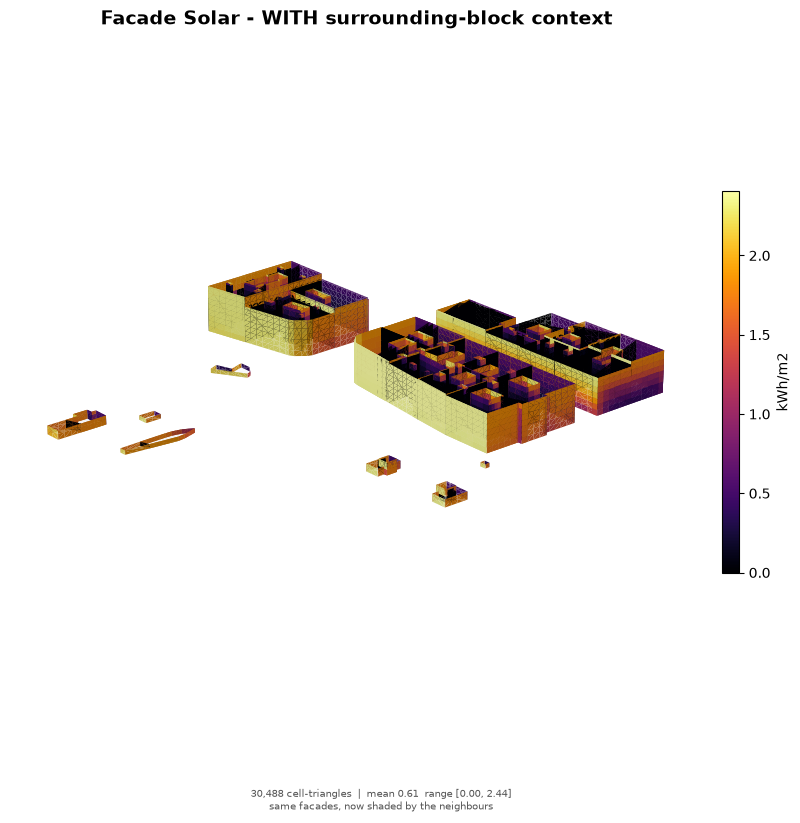

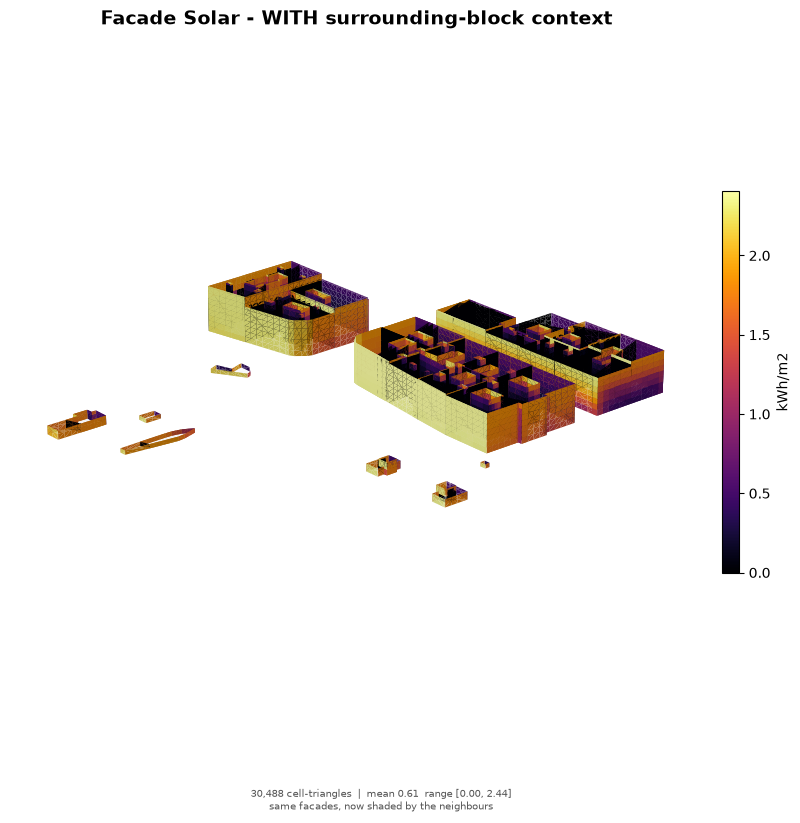

In [8]:
fig, ax = ir.surface_mesh(
    t_wi,
    v_wi,
    normals=n_wi,
    context_faces=faces,
    vmin=lo,
    vmax=hi,
    zmax=45,
    title="Facade Solar - WITH surrounding-block context",
    cbar_label="kWh/m2",
    cmap="inferno",
    note="same facades, now shaded by the neighbours",
)
fig

### Per-cell difference mesh

Color each target facade cell by **how much irradiance the context removed**
(red = shaded by neighbours). This is the clearest single view of the effect.

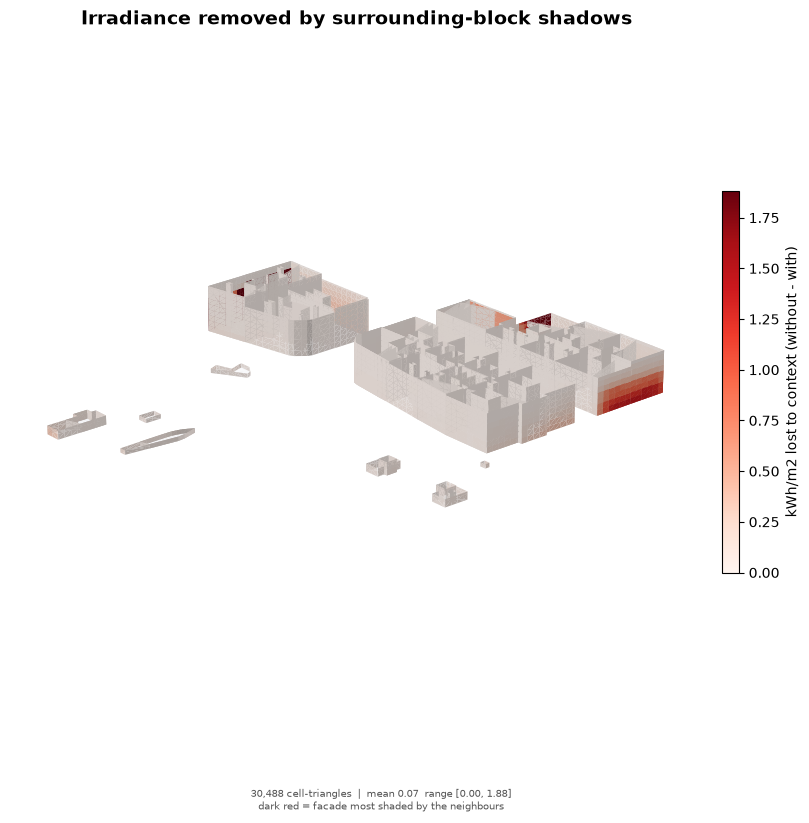

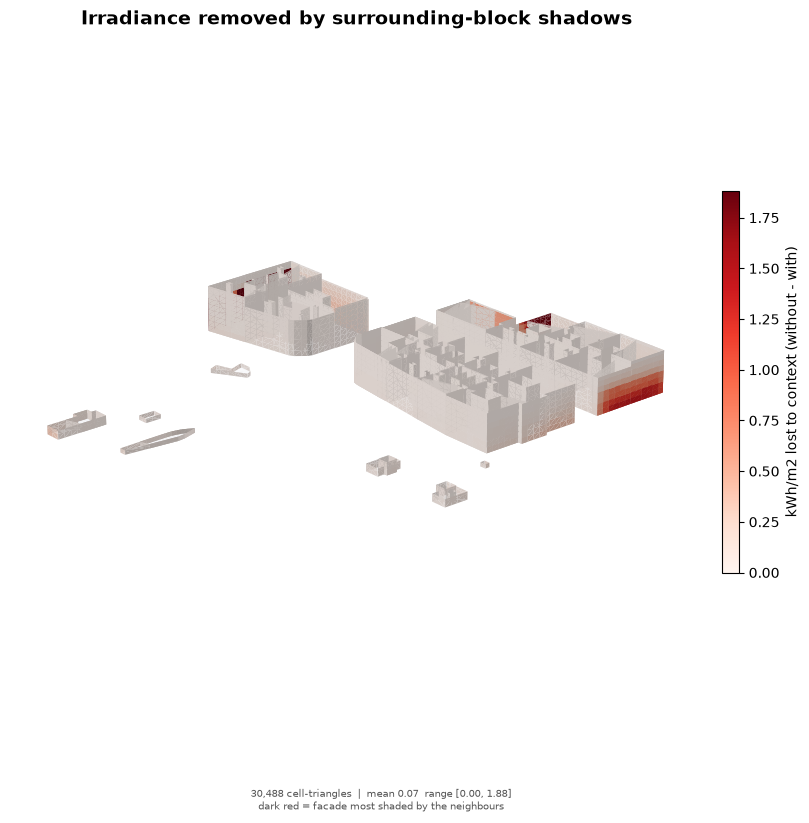

In [9]:
# Cell-triangles line up 1:1 between the two runs (identical synthesis), so
# subtract per triangle. Context can only remove irradiance, so loss >= 0.
# Plot the loss magnitude on a sequential scale: dark red = most shaded.
loss = np.clip(v_no - v_wi, 0.0, None)  # >= 0 kWh/m2 removed
fig, ax = ir.surface_mesh(
    t_wi,
    loss,
    normals=n_wi,
    context_faces=faces,
    zmax=45,
    title="Irradiance removed by surrounding-block shadows",
    cbar_label="kWh/m2 lost to context (without - with)",
    cmap="Reds",
    vmin=0.0,
    vmax=float(np.nanmax(loss)) or 1.0,
    note="dark red = facade most shaded by the neighbours",
)
fig

## Summary

* `context-geometry` brings the **surrounding blocks** into the raytrace as
  occluders without adding them to the measured set - the realistic way to run
  a facade study on a small AOI.
* Fetch a larger polygon, split target vs context, and the with / without
  comparison isolates the neighbours' shadowing.
* Needs a trigger (`analysis-surfaces` here). Not yet live on advanced UTCI
  (PR #119, pending re-deploy).